# 14 — Analisis Tren Waktu (Time Series Penjualan)

Banyak data bisnis punya **dimensi waktu**: penjualan harian, bulanan, musiman. Di notebook ini saya belajar menganalisis **tren waktu** dari data transaksi e-commerce nyata: meresample ke harian/bulanan, menghitung **moving average** (rata-rata bergerak), dan menemukan hari tersibuk.

> 🎯 **Tujuan Pembelajaran**
> - Mengubah kolom tanggal teks menjadi `datetime` (`pd.to_datetime`).
> - Membersihkan transaksi tidak valid (qty/harga ≤ 0).
> - **Resample** penjualan ke level harian & bulanan.
> - Menghitung & memplot **moving average** untuk memuluskan tren.
> - Menemukan **hari & bulan tersibuk**.

## 📊 Tentang Dataset

**E-commerce Data** ("Online Retail") berisi ±541 ribu transaksi sebuah peritel online di Inggris (Des 2010 – Des 2011). Tiap baris adalah satu item dalam sebuah faktur.

- **Sumber:** [Kaggle — carrie1/ecommerce-data](https://www.kaggle.com/datasets/carrie1/ecommerce-data)

- **Jumlah data:** ±541.909 baris × 8 kolom (dimuat dengan `encoding="latin-1"`)

| Kolom | Arti |
|-------|------|
| `InvoiceNo` | Nomor faktur (diawali 'C' = pembatalan) |
| `StockCode` | Kode produk |
| `Description` | Nama produk |
| `Quantity` | Jumlah unit (bisa negatif = retur) |
| `InvoiceDate` | Tanggal & waktu transaksi |
| `UnitPrice` | Harga satuan (GBP) |
| `CustomerID` | ID pelanggan |
| `Country` | Negara pelanggan |

Saya akan membuat kolom **`Revenue` = Quantity × UnitPrice**.

## 1.Import Library

- **pandas / numpy** → olah data tabel & angka, termasuk fitur time series.
- **matplotlib.pyplot** & **seaborn** → grafik tren.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.Import Dataset

In [4]:
!pip install -q kaggle
!kaggle datasets download -d carrie1/ecommerce-data
!unzip -qq ecommerce-data.zip


Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
ecommerce-data.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


## 3.Explorasi Data

In [5]:
df = pd.read_csv("data.csv", encoding="latin-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [10]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Interpretasi :    
- InvoiceDate masih dalam bentuk teks, perlu diubah menjadi bentuk datetime
- terdapat banyak missing value, di kolom CustomerID dan Description
- terdapat nilai minus di kolom Quantity dan UnitPrice
- Dataset terdiri dari 541909 baris dan 8 kolom

## 4.Cleaning Data

Langkah Pembersihan data:

    1. Ubah data object InvoiceData menjadi time data datetime

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


Langkah Pembersihan data:

    2.Buang atau Drop Transaksi dengen Quantity <= 0 dan Unitprice <= 0

In [12]:
before_drop = len(df)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
after_drop = len(df)
print(f"Jumlah baris sebelum drop: {before_drop}")
print(f"Jumlah baris setelah drop: {after_drop}")
print(f"Jumlah baris yang di drop: {before_drop - after_drop}")

Jumlah baris sebelum drop: 541909
Jumlah baris setelah drop: 530104
Jumlah baris yang di drop: 11805


Langkah Pembersihan data:

    3. Buat Kolom baru (Revenue) hasil dari Quantity x UnitPrice

In [13]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
print(f"Jumlah baris setelah drop: {len(df)}")
print(f"Jumlah baris yang di drop: {before_drop - after_drop}")
print("rentang tanggal :", df["InvoiceDate"].min(), "sampai", df["InvoiceDate"].max())
df[["InvoiceDate","Quantity","UnitPrice","Revenue"]].head()

Jumlah baris setelah drop: 530104
Jumlah baris yang di drop: 11805
rentang tanggal : 2010-12-01 08:26:00 sampai 2011-12-09 12:50:00


,InvoiceDate,Quantity,UnitPrice,Revenue
0,2010-12-01 08:26:00,6,2.55,15.30
1,2010-12-01 08:26:00,6,3.39,20.34
2,2010-12-01 08:26:00,8,2.75,22.00
3,2010-12-01 08:26:00,6,3.39,20.34
4,2010-12-01 08:26:00,6,3.39,20.34


Interpretasi :     

- Kita sudah membuang 11805 baris yang tidak sesuai dengan kriteria
- Data tanggal sudah diubah datatypenya menjadi datetime
- Data baru (revenue) sudah dibuat untuk mempermudah mengaggregasikan hasil selanjutnya

## 5.Trend Daily Sales

Saya jadikan `InvoiceDate` sebagai indeks waktu lalu **resample** harian (`"D"`) untuk menjumlahkan revenue per hari.

### Grafik 1 - Revenue HARIAN

In [16]:
time_series = df.set_index("InvoiceDate").sort_index()
daily_sales = time_series["Revenue"].resample("D").sum()

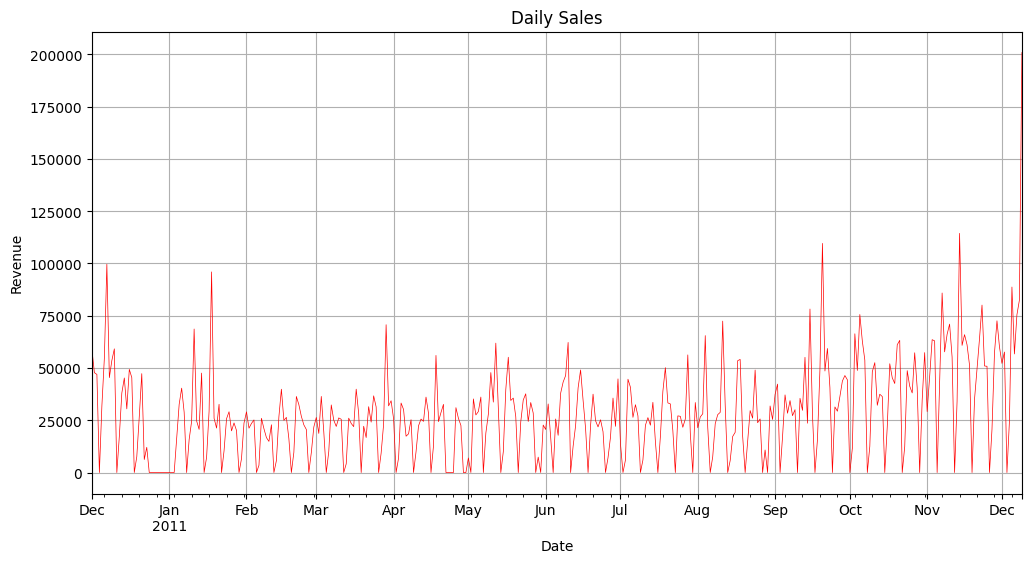

In [20]:
#Visualize
plt.figure(figsize=(12,6))
daily_sales.plot(color="red", linewidth=0.5)

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

Interpretasi:
-  Revenue harian cenderung flutuatif( naik turun tajam )
- terhilat cenderung meningkat di menjelang akhir tahun 2011
- terlihat garis datar pada akhir tahun 2011 ( menandakan adanya libur dalam operasional marketplace ) hari tanpa transaksi

## 6.Memuluskan Trend : Moving Average

Moving Avarege (rata-rata bergerak) merata-ratakan beberapa hari berturut turut sehingga fluktuasi harian terendam dan tren terlihat lebih jelas, pakai 7 days dan 30 days untuk windownya

### Grafik 2 - Revenue Harian + Moving Average 7 & 30 Hari

In [23]:
MA_7 = daily_sales.rolling(window=7).mean()
MA_30 = daily_sales.rolling(window=30).mean()

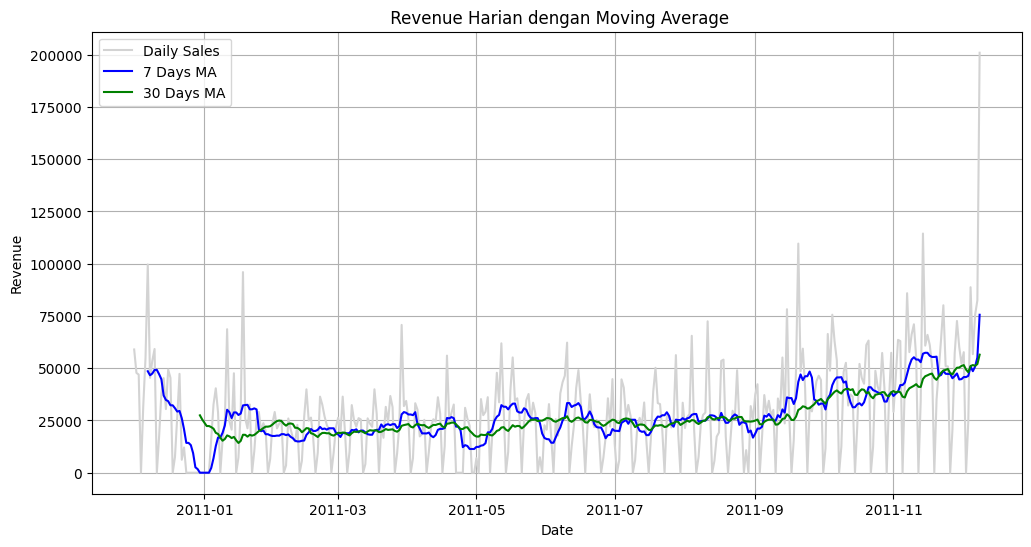

In [27]:
plt.figure(figsize=(12,6))


plt.plot(daily_sales.index, daily_sales.values, color="lightgray", label="Daily Sales")
plt.plot(MA_7.index, MA_7.values, color="blue", label="7 Days MA")
plt.plot(MA_30.index, MA_30.values, color="green", label="30 Days MA")

plt.title(" Revenue Harian dengan Moving Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()




Interpretasi :

Tren Utama

  - Fluktuasi Harian yang Tajam: Garis abu-abu menunjukkan bahwa revenue harian sangat berfluktuasi naik-turun secara drastis setiap harinya, bahkan beberapa kali sempat menyentuh angka 0 (atau sangat rendah).

  - Stagnasi di Paruh Pertama Tahun (Januari – Agustus): Dari awal tahun hingga sekitar bulan Agustus 2011, pergerakan tren (garis biru dan hijau) cenderung mendatar di kisaran angka 20.000 hingga 30.000, menandakan penjualan yang stabil namun tidak ada pertumbuhan yang signifikan.

  - Lonjakan Signifikan di Akhir Tahun (September – Desember): Memasuki bulan September hingga akhir tahun 2011, terjadi kenaikan tren revenue yang konsisten dan cukup tajam. Puncaknya terlihat pada bulan November hingga Desember di mana garis MA 7 dan MA 30 merangkak naik melewati angka 50.000, serta lonjakan harian (spike) tertinggi mencapai kisaran 100.000 hingga 200.000.

Fungsi Moving Average pada Grafik

  - 7 Days MA (Biru): Lebih sensitif menangkap perubahan tren jangka pendek dan mengikuti pola mingguan. Garis ini terlihat lebih sering berfluktuasi di sekitar garis hijau.

  - 30 Days MA (Hijau): Menunjukkan tren bulanan jangka panjang yang lebih mulus (smooth), mengabaikan kebisingan (noise) harian dan memperlihatkan arah bisnis secara keseluruhan—yakni stabil di awal tahun dan mengalami growth (pertumbuhan) pesat menjelang akhir tahun (kemungkinan besar karena periode musiman seperti holiday season atau akhir tahun).

## 7.Trend Bulanan ( Revenue Bulanan )

Untuk gambaran besar, kita agregasi revenue per **bulan**.

### Grafik 3 - Revenue Bulanan

In [28]:
monthly_sales = time_series["Revenue"].resample("M").sum()

/tmp/ipykernel_2695/1319011958.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = time_series["Revenue"].resample("M").sum()


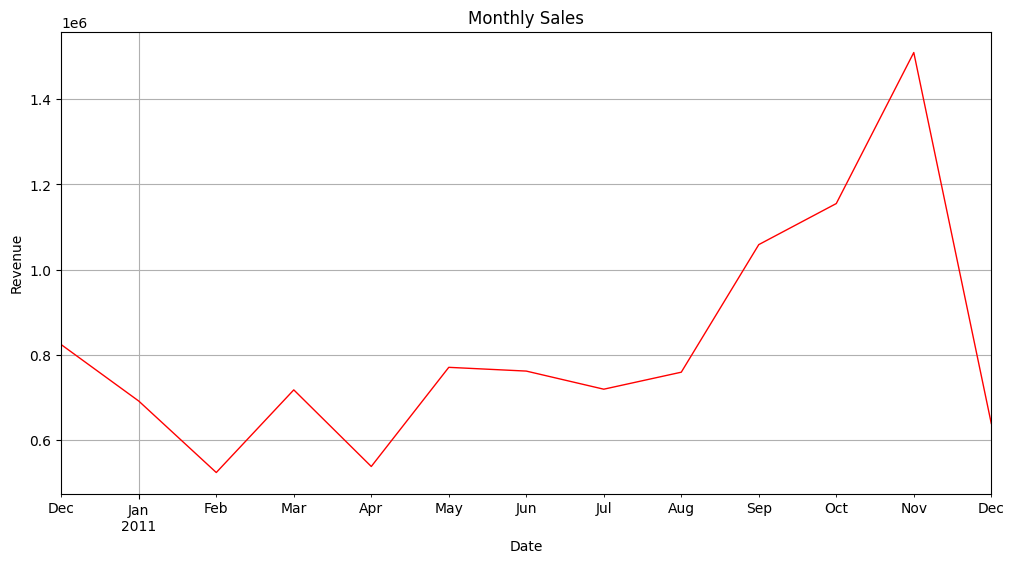

In [32]:
plt.figure(figsize=(12,6))
monthly_sales.plot(color="red", linewidth=1)

plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

Interpretasi:

Pola dan Temuan Utama

  - Stabilitas di Paruh Pertama (Desember 2010 – Agustus 2011): Penjualan bulanan berfluktuasi relatif stabil di kisaran 0.6 hingga 0.8 juta (600.000 – 800.000). Titik terendah tercatat pada bulan Februari dan April 2011.

  - Lonjakan Signifikan (September – November 2011): Mulai bulan September, grafik menunjukkan kenaikan yang sangat tajam dan konsisten setiap bulannya. Pendapatan melonjak dari sekitar 1 juta di bulan September, naik ke 1.15 juta di Oktober, hingga mencapai puncak tertinggi (peak) di bulan November mendekati 1.5 juta.

  - Penurunan Tajam di Bulan Desember: Setelah puncak pencapaian di bulan November, penjualan langsung merosot tajam kembali ke kisaran 0.6 juta pada bulan Desember.

Insight Bisnis

  - Musiman (Seasonality): Bisnis ini memiliki pola musiman akhir tahun yang sangat kuat (holiday season / Q4 surge), di mana aktivitas belanja melonjak drastis pada bulan September hingga November.

  - Anomali Desember: Penurunan drastis pada bulan Desember kemungkinan besar terjadi karena data pada bulan tersebut belum penuh atau tercatat hanya sampai awal bulan Desember (mengingat kurva langsung jatuh mendekati garis tepi akhir).

## 8.Hari Tersibuk dalam 1 Minggu

Apakah ada hari yang konsisten lebih ramai? Kita kelompokkan revenue berdasarkan **nama hari**.

### Grafik 4 - Revenue rata rata per hari dalam seminggu

In [33]:
nama_hari = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
nama_hari_id = {"Monday":"Senin","Tuesday":"Selasa","Wednesday":"Rabu","Thursday":"Kamis",
           "Friday":"Jumat","Saturday":"Sabtu","Sunday":"Minggu"}

In [35]:
df["day"] = df["InvoiceDate"].dt.day_name()
eachday = df.groupby("day")["Revenue"].sum().reindex(nama_hari)

/tmp/ipykernel_2695/3842525991.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[nama_hari_id[h] for h in eachday.index],


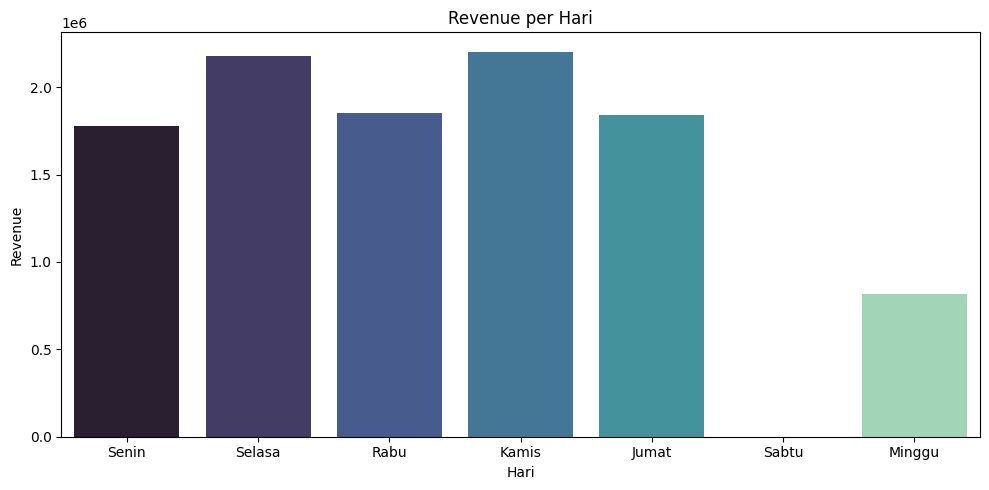

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(x=[nama_hari_id[h] for h in eachday.index],
            y=eachday.values,
            palette="mako")

plt.title("Revenue per Hari")
plt.xlabel("Hari")
plt.ylabel("Revenue")
plt.tight_layout()
#annote
plt.show()


Interpretasi
- Transaksi kosong di hari sabtu
- para penjual mungkin tutup di hari weekend tertentu, atau ada regulasi dari pemerintah setempat mengenai kebijakan hari libur untuk marketplace, sehingga toko bisa melakukan aktivitas lainnya diluar perniagaan, seperti stock opname atau meliburkan pekerjanya

## Kesimpulan & Insight

- `pd.to_datetime` + `set_index` + `resample` adalah trio inti analisis time series di pandas.
- Penjualan harian sangat berfluktuasi; **moving average** mengungkap tren sebenarnya.
- Terdapat **tren musiman**: revenue memuncak menjelang **Natal 2011**.
- Pola mingguan menunjukkan **hari kerja lebih ramai**, dan toko tidak berjualan di hari Sabtu.
- Selalu waspadai **periode data yang terpotong** (Desember 2011) saat menafsirkan tren.

Pemahaman tren waktu ini menjadi dasar untuk peramalan (forecasting) di proyek lanjutan.

## 💼 Rekomendasi & Insight Bisnis

Pola musiman (puncak menjelang Natal) dan ritme mingguan langsung dapat ditindaklanjuti:
**rencanakan stok, staf, dan kampanye** mengikuti periode ramai, bukan rata-rata sepanjang tahun.

### ⚠️ Jebakan Data
- **Desember 2011 terpotong** (data berhenti di tengah bulan). Tanpa disadari, ini terlihat seperti
  "penjualan anjlok" — padahal hanya datanya yang belum lengkap. Selalu cek **rentang tanggal**.
- Kolom `Quantity` memuat nilai **negatif** (retur/pembatalan). Wajib difilter sebelum menghitung
  revenue, kalau tidak total jadi salah.